# Distance-3 Surface Code Simulator

This notebook demonstrates the usage of the `qec` package.

Features:
- Distance-3 planar surface code
- Syndrome extraction
- MWPM decoding
- Space-time decoding
- Depolarising and readout noise models

The implementation lives in `src/qec/`.

In [1]:
# Import dependencies

import sys
from pathlib import Path
from qiskit import transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from qec.noise import depol_noise_model
from qec.circuit import one_round_surface_d3
from qec.simulation import compare_single_vs_spacetime
from qec.visualization import plot_decoder_comparison


## Single-round syndrome extraction

In [2]:
sim = AerSimulator()
basis = ['id','rz','sx','x','h','cx','measure']

qc = one_round_surface_d3()
tc = transpile(qc, sim, basis_gates=basis, optimization_level=1)

noise = depol_noise_model(p1=0.01, ro=0.01)   # tweak p1 to see more/less defects
res = sim.run(tc, shots=2000, noise_model=noise).result()
counts = res.get_counts()

print("num distinct syndromes:", len(counts))
list(counts.items())[:5]

# quick parse: convert bitstring 'xxxxzzzz' -> (X_syndrome, Z_syndrome)
def parse_syndrome(bitstr, n_x=4):
    s = bitstr.replace(' ', '')  # just in case
    s = s[::-1]
    return s[:n_x], s[n_x:]

# show top-5 most common syndromes
top = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:5]
for bits, n in top:
    xs, zs = parse_syndrome(bits, 4)
    print(f"{bits:>10}  shots={n:4d}   X={xs}  Z={zs}")

c:\wzf\学习\qec-surface-code-sim\.venv\Lib\site-packages\qiskit\compiler\transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


num distinct syndromes: 256
  10100110  shots=  20   X=0110  Z=0101
  01001011  shots=  16   X=1101  Z=0010
  01001001  shots=  16   X=1001  Z=0010
  01100011  shots=  15   X=1100  Z=0110
  11011111  shots=  15   X=1111  Z=1011


## Compare Single-Round and Space-Time Decoding

Run a sweep over physical depolarising error rates and compare:

- Single-round decoding
- Multi-round space-time decoding

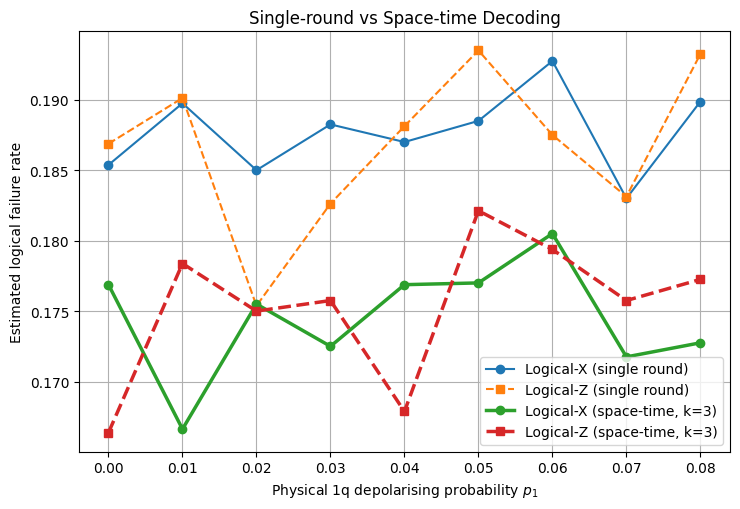

In [3]:
p_vals = np.linspace(0.0, 0.08, 9)

results = compare_single_vs_spacetime(
    p_vals,
    k_space_time=3,
    k_single=1,
    shots=8000,
    ro=0.01,
)

plot_decoder_comparison(
    *results,
)

## Results

The figure compares logical failure rates obtained using:

- Single-round MWPM decoding
- Space-time MWPM decoding

The current implementation demonstrates syndrome extraction and decoding workflows for a distance-3 surface code.

Future work:

- Distance-5 and distance-7 codes
- Threshold studies
- Stim integration
- PyMatching backend
- Improved logical observable tracking